In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('Data all.csv')

In [4]:
data.head()

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,referral,ward,antib_prior_admi,sympt_dura,hiv_status,...,Prescribed_antib_1,Prescribed_antib_2,Prescribed_antib_3,organism_isolated,first_organism,sec_organism,Resistance,Antibioitic_aft_cul_1,complications,length_hosp_stay
0,0,6.0,0,1,4,1,3,1,2,2,...,17,7,3,3,13,10,0,15,0,12.0
1,0,13.0,0,6,6,1,2,1,0,0,...,11,7,3,3,13,10,0,15,0,8.0
2,0,11.0,0,11,4,0,3,1,2,2,...,3,4,3,3,13,10,0,15,1,14.0
3,0,18.0,0,10,4,1,4,1,2,2,...,21,14,3,0,4,10,1,15,1,0.0
4,0,17.0,1,10,4,1,1,1,2,1,...,5,20,11,0,9,10,1,6,1,10.0


In [5]:
data.columns

Index(['name_of_rrh', 'age', 'sex', 'Infection_Site_1', 'Infection_Site_2',
       'referral', 'ward', 'antib_prior_admi', 'sympt_dura', 'hiv_status',
       'cormobid_condition', 'Prescribed_antib_1', 'Prescribed_antib_2',
       'Prescribed_antib_3', 'organism_isolated', 'first_organism',
       'sec_organism', 'Resistance', 'Antibioitic_aft_cul_1', 'complications',
       'length_hosp_stay'],
      dtype='object')

In [6]:
data.isna().sum()

name_of_rrh              0
age                      0
sex                      0
Infection_Site_1         0
Infection_Site_2         0
referral                 0
ward                     0
antib_prior_admi         0
sympt_dura               0
hiv_status               0
cormobid_condition       0
Prescribed_antib_1       0
Prescribed_antib_2       0
Prescribed_antib_3       0
organism_isolated        0
first_organism           0
sec_organism             0
Resistance               0
Antibioitic_aft_cul_1    0
complications            0
length_hosp_stay         0
dtype: int64

In [7]:
growth1 = data[[
                'name_of_rrh',
                'ward', 
                'age', 
                'sex', 
                'cormobid_condition', 
                'Resistance', 
                'length_hosp_stay', 
                'referral',
                'organism_isolated',
                'hiv_status'
               ]]

In [8]:
growth1.head()

,name_of_rrh,ward,age,sex,cormobid_condition,Resistance,length_hosp_stay,referral,organism_isolated,hiv_status
0,0,3,6.0,0,0,0,12.0,1,3,2
1,0,2,13.0,0,0,0,8.0,1,3,0
2,0,3,11.0,0,1,0,14.0,0,3,2
3,0,4,18.0,0,0,1,0.0,1,0,2
4,0,1,17.0,1,1,1,10.0,1,0,1


In [9]:
from sklearn.model_selection import train_test_split


X = growth1.drop(columns =['length_hosp_stay'])
y = growth1['length_hosp_stay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [10]:
import mlflow
from mlflow.models import infer_signature
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Huber model

2025/04/24 10:05:27 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inf

Mean Absolute Error: 22063622289372137038267105056145151147428712586149888.00
Root Mean Squared Error: 188270242623237092861117510042032478233840343849107456.00
R-squared Score: -0.0139


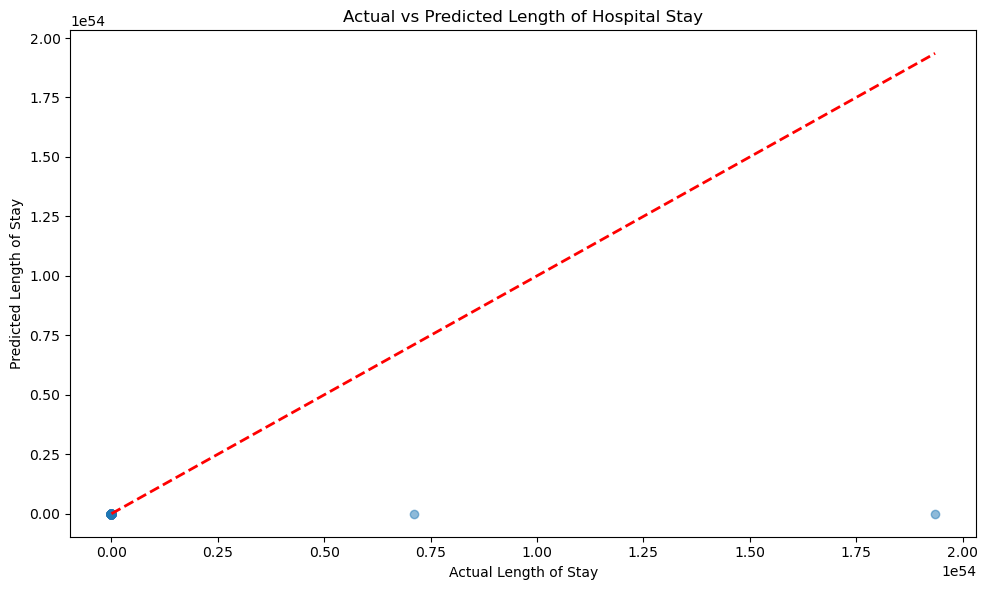

In [11]:
from sklearn.linear_model import HuberRegressor

# Define the model hyperparameters
params = {
    'epsilon': 2,
    'max_iter': 1500,
    'alpha': 0.001
}

# Train the model
huber = HuberRegressor(**params)
huber.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = huber.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(huber, "huber_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay')
plt.tight_layout()
plt.show()

# Random Forest Regressor

/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Mean Absolute Error: 14.42
Root Mean Squared Error: 23.66
R-squared Score: -0.0148


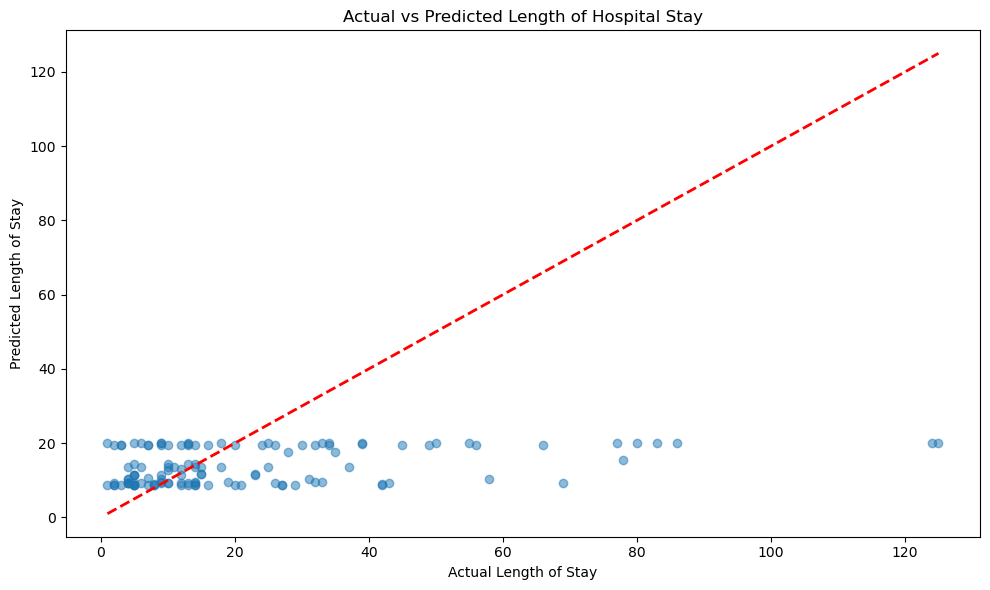

In [12]:
import mlflow
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters
params = {
    'random_state':1,
    'n_estimators': 1750, 
    'min_samples_split': 6, 
    'min_samples_leaf': 2, 
    'max_features': 0.8, 
    'max_depth': 2, 
    'bootstrap': False
}

rf = RandomForestRegressor(**params)
rf.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(rf, "Rf_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay')
plt.tight_layout()
plt.show()

In [13]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow RandomForest Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Random Forest Regressor model")

    # Infer the model signature
    signature = infer_signature(X_train, rf.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="RandomForest Regressor model",
    )

MlflowException: API request to http://127.0.0.1:8080/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='127.0.0.1', port=8080): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=MLflow+RandomForest+Regressor+model (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7c3714091e80>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
# Load the model back for predictions as a generic Python Function model
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

y_pred_log = loaded_model.predict(X_test)

dataset_names = growth1.columns

predictions = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  

result = pd.DataFrame(X_test, columns=dataset_names)
result["actual_class"] = y_test_original
result["predicted_class"] = predictions

result[:10]

,name_of_rrh,ward,age,sex,cormobid_condition,Resistance,length_hosp_stay,referral,organism_isolated,hiv_status,actual_class,predicted_class
188,3,4,38.0,0,0,0,NaN,0,3,2,20.0,1.268096e+06
238,3,3,2.0,0,0,1,NaN,0,0,2,5.0,5.398500e+08
462,6,1,22.0,1,0,0,NaN,1,3,0,26.0,6.140687e+05
465,6,4,14.0,0,1,1,NaN,0,0,0,15.0,9.837616e+09
182,2,2,25.0,0,0,0,NaN,0,3,0,5.0,5.021949e+05
300,4,4,43.0,1,1,1,NaN,0,0,1,80.0,5.003834e+09
101,1,4,16.0,0,0,1,NaN,1,0,2,12.0,7.132358e+10
286,4,2,12.0,0,1,0,NaN,1,3,1,8.0,2.231504e+06
388,5,0,0.0,0,0,0,NaN,1,3,0,33.0,6.019478e+05
566,8,4,22.0,1,0,1,NaN,0,1,2,1.0,1.241845e+08



Feature Importance with Best Parameters:
              feature  importance
5          Resistance    0.475738
2                 age    0.213987
0         name_of_rrh    0.140133
7   organism_isolated    0.102306
1                ward    0.043868
8          hiv_status    0.021496
3                 sex    0.001845
4  cormobid_condition    0.000627
6            referral    0.000000


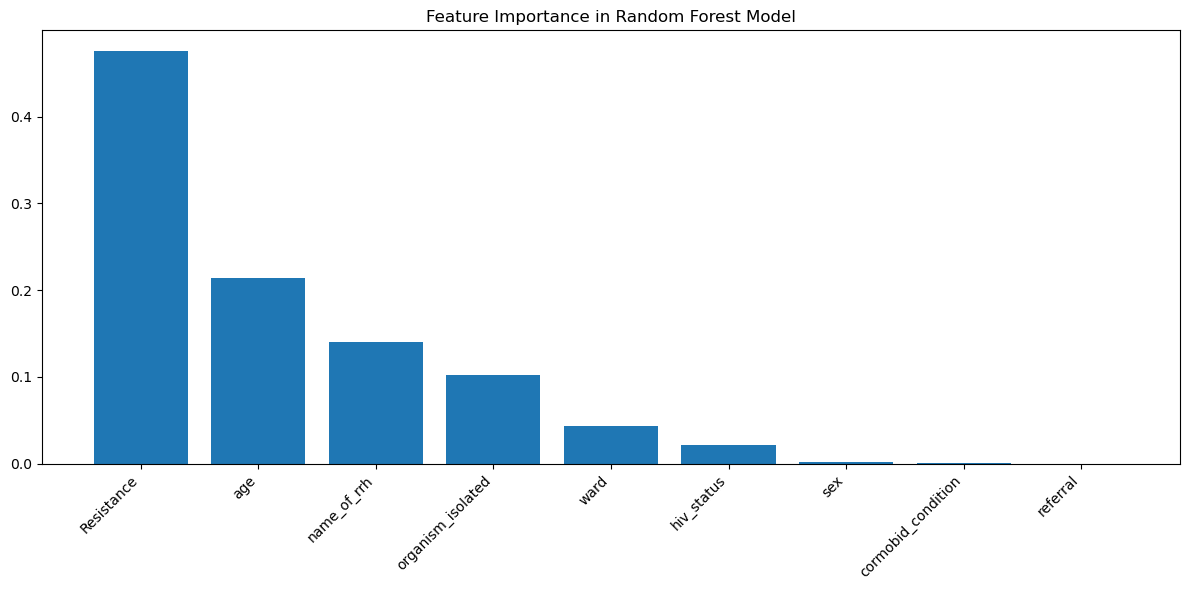

In [ ]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\nFeature Importance with Best Parameters:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance in Random Forest Model')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error
import pandas as pd

# Prepare the data
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])

# Define custom scorer for original scale RMSE
def custom_rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

rmse_scorer = make_scorer(custom_rmse_scorer, greater_is_better=False)

# Define parameter distributions
param_dist = {
    'n_estimators': [500, 750, 1000, 1250],
    'max_features': [0.6, 0.7, 0.8, 0.9],
    'min_samples_split': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_depth': [None, 4, 8, 10],
    'bootstrap': [True, False]
}

# Create Random Forest model
rf = RandomForestRegressor(random_state=1)

# Perform randomized search
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring=rmse_scorer,
    n_jobs=-1,
    random_state=1,
    verbose=1
)

# Fit the random search
random_search.fit(X, y)

# Print results
print("Best parameters found:")
print(random_search.best_params_)
print("\nBest RMSE:", -random_search.best_score_)

# Get all results
results = pd.DataFrame(random_search.cv_results_)
results = results.sort_values('mean_test_score', ascending=False)

# Print top 5 combinations
print("\nTop 5 parameter combinations:")
for i in range(5):
    params = results.iloc[i]['params']
    score = -results.iloc[i]['mean_test_score']
    std = results.iloc[i]['std_test_score']
    print(f"\nRank {i+1}:")
    print(f"Parameters: {params}")
    print(f"RMSE: {score:.2f} (+/- {std*2:.2f})")

# Train best model and get feature importance
best_model = RandomForestRegressor(**random_search.best_params_, random_state=1)
best_model.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:
{'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': 4, 'bootstrap': True}

Best RMSE: 35.99149808326292

Top 5 parameter combinations:

Rank 1:
Parameters: {'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': 4, 'bootstrap': True}
RMSE: 35.99 (+/- 37.11)

Rank 2:
Parameters: {'n_estimators': 500, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 4, 'bootstrap': True}
RMSE: 36.02 (+/- 36.99)

Rank 3:
Parameters: {'n_estimators': 750, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 4, 'bootstrap': True}
RMSE: 36.02 (+/- 37.04)

Rank 4:
Parameters: {'n_estimators': 1000, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 4, 'bootstrap': True}
RMSE: 36.04 (+/- 36.93)

Rank 5:
Parameters: {'n_estimators': 1000, 

RandomForestRegressor(max_depth=4, max_features=0.6, min_samples_split=10,
                      n_estimators=1000, random_state=1)

# Gradient boost regressor

/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run handsome-eel-31 at: http://127.0.0.1:8080/#/experiments/320510952361426209/runs/a60f133833ce47c9b1191ba8097b975d
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/320510952361426209
Mean Absolute Error: 13.94
Root Mean Squared Error: 23.84
R-squared Score: -0.0303


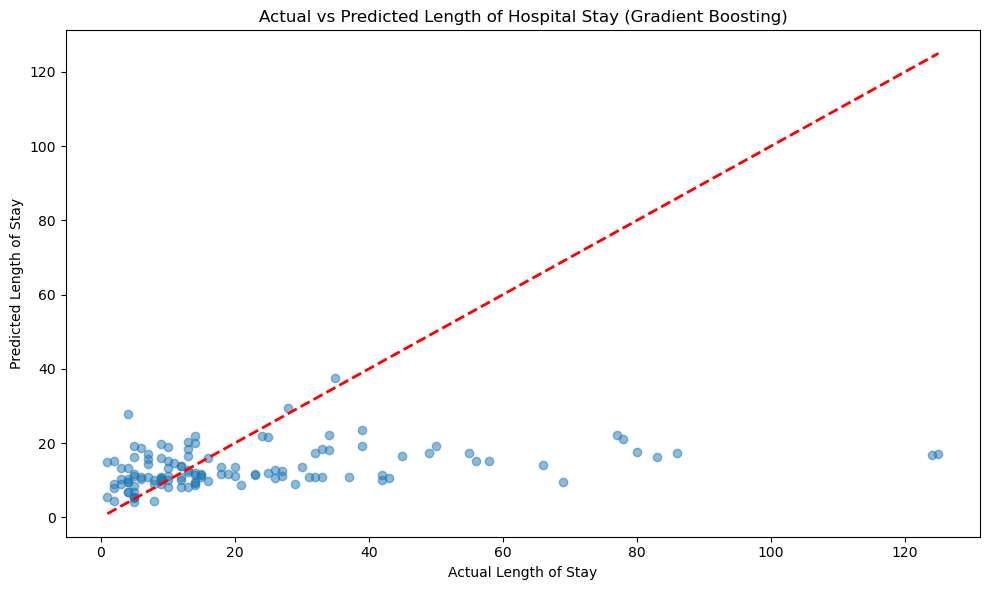

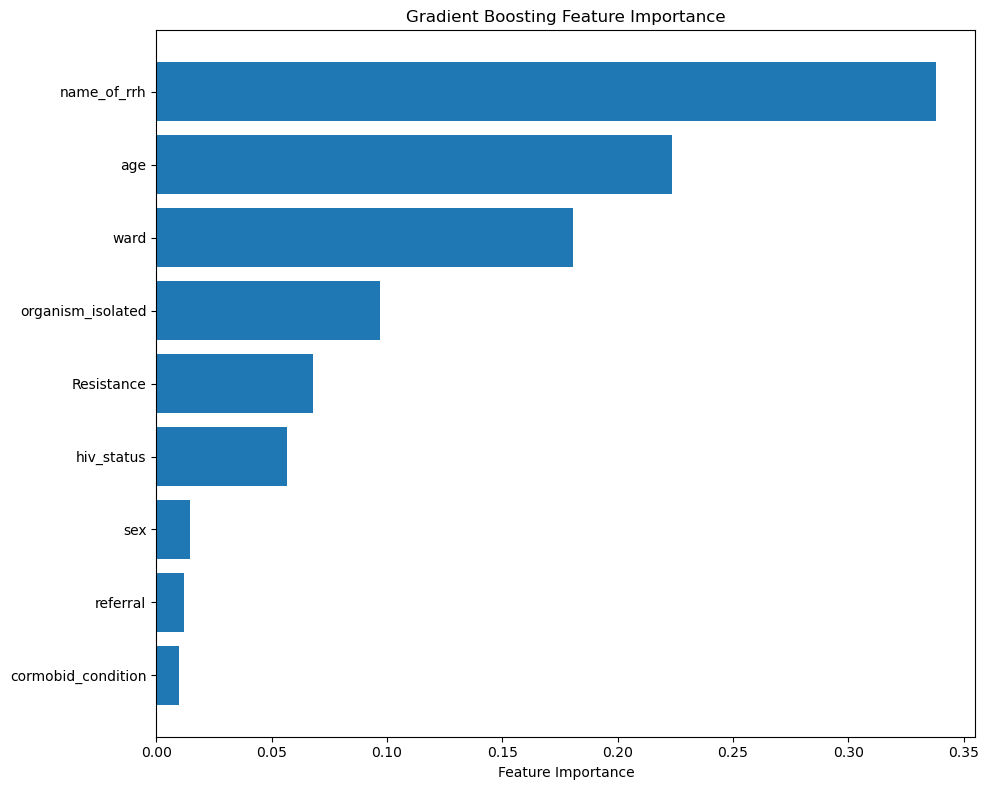

In [ ]:
import mlflow
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters for Gradient Boosting
params = {
    'random_state': 42,
    'n_estimators': 1500,         # Significantly increased for better fit
    'learning_rate': 0.005,       # Further reduced for more precise corrections
    'max_depth': 2,               # Increased to capture more complex patterns
    'min_samples_split': 2,       # Minimum value to create highly specialized trees
    'min_samples_leaf': 1,        # Minimum value for maximum tree detail
    'subsample': 1,            # Increased to use more of the training data
    'max_features': 0.69,          # Using most features for splits
    'validation_fraction': 0.2,   # For early stopping
    'n_iter_no_change': 100,      # For early stopping
    'tol': 1e-5                   # For early stopping
}


# Initialize and train the Gradient Boosting Regressor
gb = GradientBoostingRegressor(**params)
gb.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = gb.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(gb, "GB_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
          [y_test_original.min(), y_test_original.max()],
          'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Gradient Boosting)')
plt.tight_layout()
plt.show()

# Feature importance plot
feature_importance = gb.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow GB Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "GB_regressor_model")

    # Infer the model signature
    signature = infer_signature(X_train, gb.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="GB Regressor model",
    )

/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'GB Regressor model' already exists. Creating a new version of this model...
2025/03/04 12:21:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model 

🏃 View run victorious-fly-185 at: http://127.0.0.1:8080/#/experiments/442355567818203334/runs/2caa28a6c688487f8a5fd1d74a1e9198
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/442355567818203334


Created version '33' of model 'GB Regressor model'.


Starting hyperparameter tuning with RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END learning_rate=0.010699098521619942, max_depth=6, max_features=0.9692763545078751, min_samples_leaf=2, min_samples_split=13, n_estimators=3324, subsample=0.8852444528883149; total time=   0.2s
[CV] END learning_rate=0.004745401188473625, max_depth=7, max_features=0.5917173949330818, min_samples_leaf=8, min_samples_split=14, n_estimators=2638, subsample=0.8337498258560773; total time=   0.3s
[CV] END learning_rate=0.010699098521619942, max_depth=6, max_features=0.9692763545078751, min_samples_leaf=2, min_samples_split=13, n_estimators=3324, subsample=0.8852444528883149; total time=   0.3s
[CV] END learning_rate=0.010699098521619942, max_depth=6, max_features=0.9692763545078751, min_samples_leaf=2, min_samples_split=13, n_estimators=3324, subsample=0.8852444528883149; total time=   0.3s
[CV] END learning_rate=0.010699098521619942, max_depth=6, max_features=0.969

/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run silent-cow-846 at: http://127.0.0.1:8080/#/experiments/442355567818203334/runs/6ab4824ece0a4131aa6c2f20db0269e0
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/442355567818203334

Final Model Performance on Test Set:
Mean Absolute Error: 14.38
Root Mean Squared Error: 24.11
R-squared Score: -0.0535


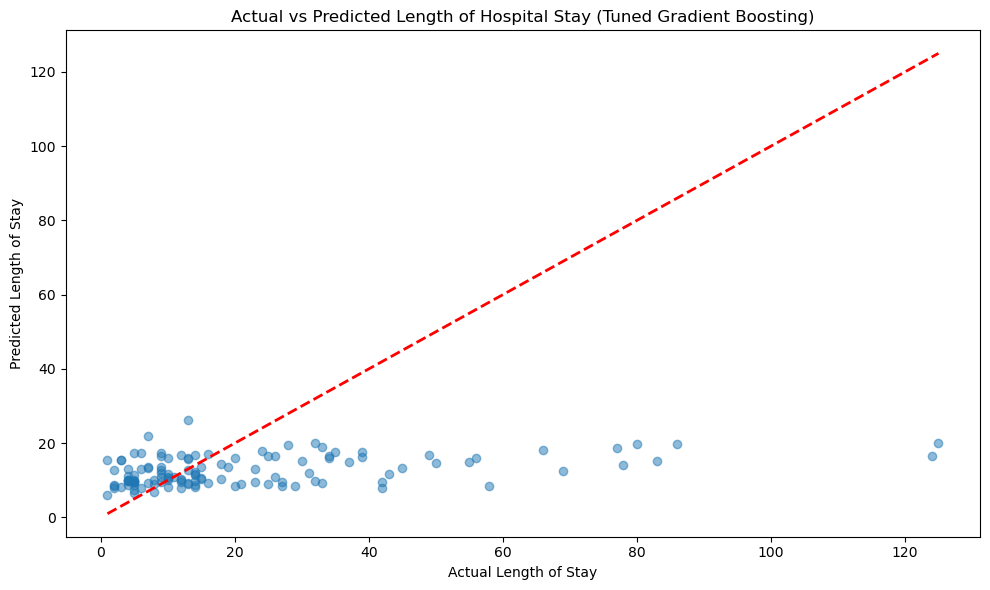

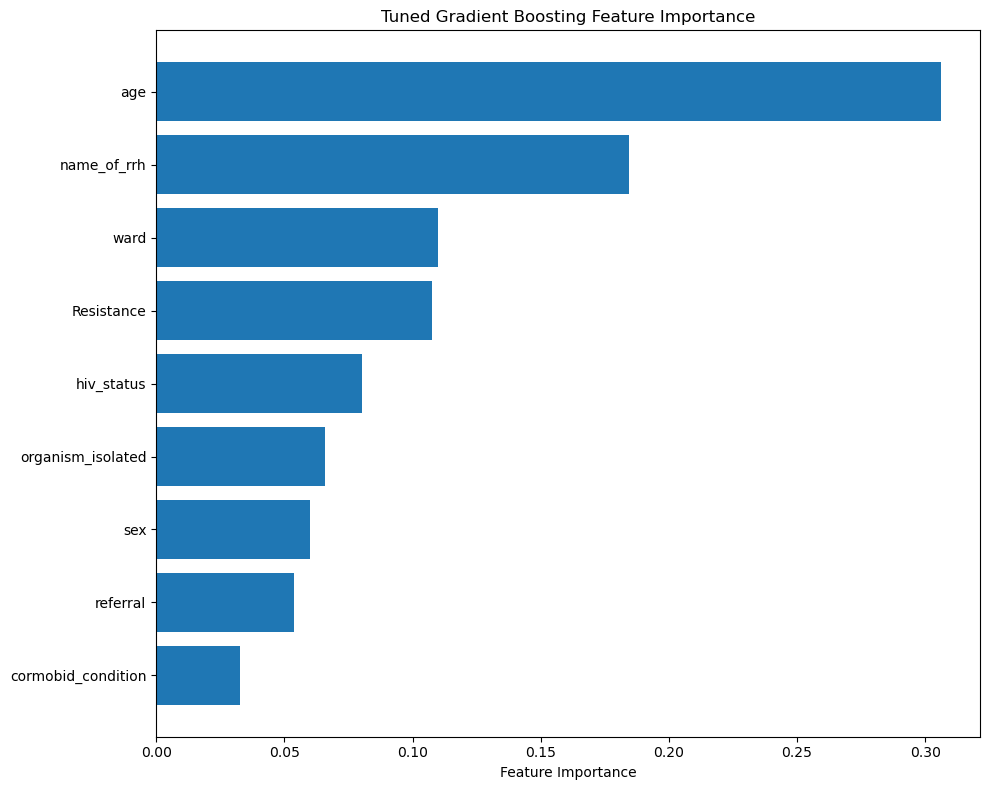

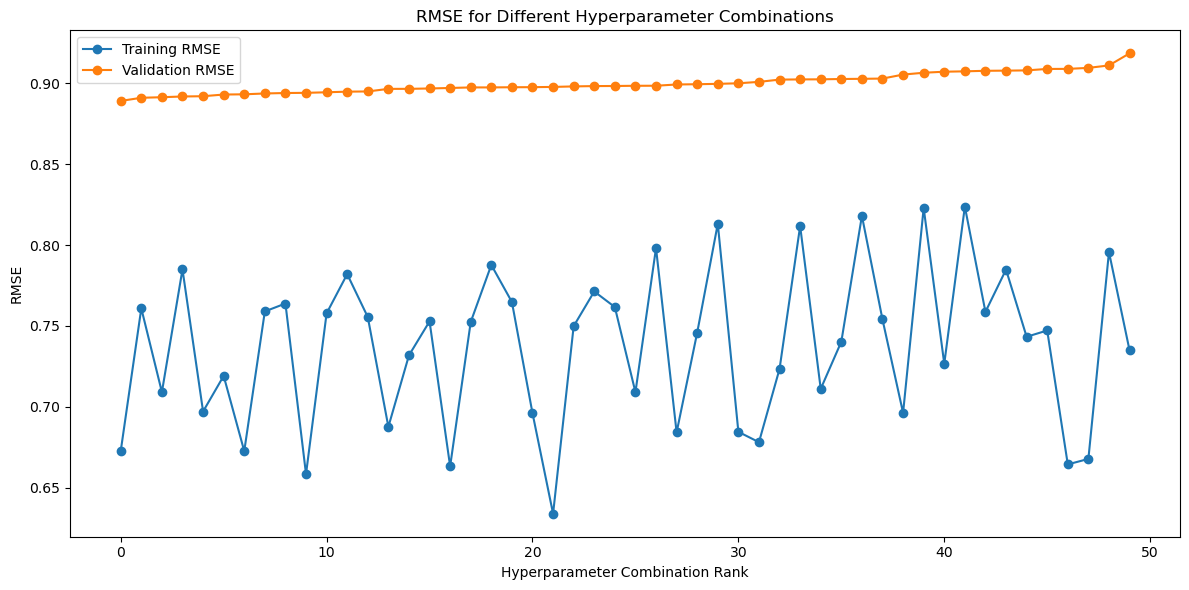

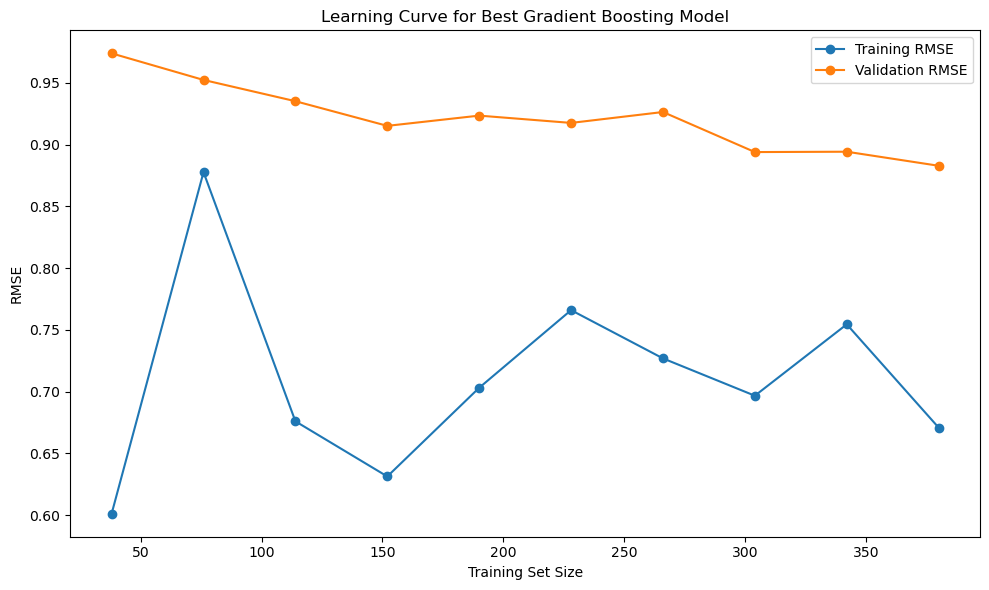

In [ ]:
import mlflow
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform

# Apply log transformation to the target variable
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the hyperparameter search space for Gradient Boosting
param_distributions = {
    'n_estimators': randint(1000, 3500),
    'learning_rate': uniform(0.001, 0.01),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'subsample': uniform(0.7, 0.3),  # This means from 0.7 to 1.0
    'max_features': uniform(0.5, 0.5),  # This means from 0.5 to 1.0
    # 'loss': ['ls'],  # Since we're focused on squared error
}

# Initialize the base model
base_model = GradientBoostingRegressor(
    random_state=10,
    validation_fraction=0.2,
    n_iter_no_change=50,
    tol=1e-5
)

# Set up cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings sampled
    cv=cv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,  # Use all available processors
    verbose=2,
    return_train_score=True
)

# Perform the randomized search
print("Starting hyperparameter tuning with RandomizedSearchCV...")
random_search.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found:")
print(random_search.best_params_)
print(f"Best RMSE: {np.sqrt(-random_search.best_score_)}")

# Get the best model
best_gb = random_search.best_estimator_

# Make predictions and inverse transform them
y_pred_log = best_gb.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the best model and metrics with MLflow
with mlflow.start_run():
    # Log best parameters
    mlflow.log_params(random_search.best_params_)
    
    # Log metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(best_gb, "best_GB_regressor_model", signature=signature)

# Print the metrics
print("\nFinal Model Performance on Test Set:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Create a scatter plot to visualize predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Tuned Gradient Boosting)')
plt.tight_layout()
plt.savefig('gb_predictions_vs_actual.png')
plt.show()

# Feature importance plot for the best model
feature_importance = best_gb.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Tuned Gradient Boosting Feature Importance')
plt.tight_layout()
plt.savefig('gb_feature_importance.png')
plt.show()

# Plot learning curves of the hyperparameter search
results = random_search.cv_results_
plt.figure(figsize=(12, 6))

# Get indices sorted by rank
sorted_indices = np.argsort(results['rank_test_score'])

# Plot the RMSE for each hyperparameter combination
train_scores = -results['mean_train_score'][sorted_indices]
test_scores = -results['mean_test_score'][sorted_indices]
plt.plot(range(len(sorted_indices)), np.sqrt(train_scores), 'o-', label='Training RMSE')
plt.plot(range(len(sorted_indices)), np.sqrt(test_scores), 'o-', label='Validation RMSE')
plt.xlabel('Hyperparameter Combination Rank')
plt.ylabel('RMSE')
plt.title('RMSE for Different Hyperparameter Combinations')
plt.legend()
plt.tight_layout()
plt.savefig('gb_hyperparameter_search_results.png')
plt.show()

# Optional: Plot learning curve of the best model
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    best_gb, X_train, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Calculate RMSE from MSE
train_rmse = np.sqrt(-np.mean(train_scores, axis=1))
valid_rmse = np.sqrt(-np.mean(valid_scores, axis=1))

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE')
plt.plot(train_sizes, valid_rmse, 'o-', label='Validation RMSE')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve for Best Gradient Boosting Model')
plt.legend()
plt.tight_layout()
plt.savefig('gb_learning_curve.png')
plt.show()

# Light gradient boost regressor

[LightGBM] [Warning] lambda_l2 is set=0.012564940721149519, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.012564940721149519
[LightGBM] [Warning] lambda_l1 is set=0.0004944664348756718, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004944664348756718
[LightGBM] [Warning] lambda_l2 is set=0.012564940721149519, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.012564940721149519
[LightGBM] [Warning] lambda_l1 is set=0.0004944664348756718, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004944664348756718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93
[LightGBM] [Info] Number of data points in the train set: 476, number of used features: 9
[LightGBM] [Info] Start training from score 2.645756
[LightGBM] [Warning] No further splits with p

/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run industrious-hawk-628 at: http://127.0.0.1:8080/#/experiments/442355567818203334/runs/3c730738a4034a9d84fad242fd1c1ccd
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/442355567818203334
Mean Absolute Error: 14.24
Root Mean Squared Error: 23.81
R-squared Score: -0.0274


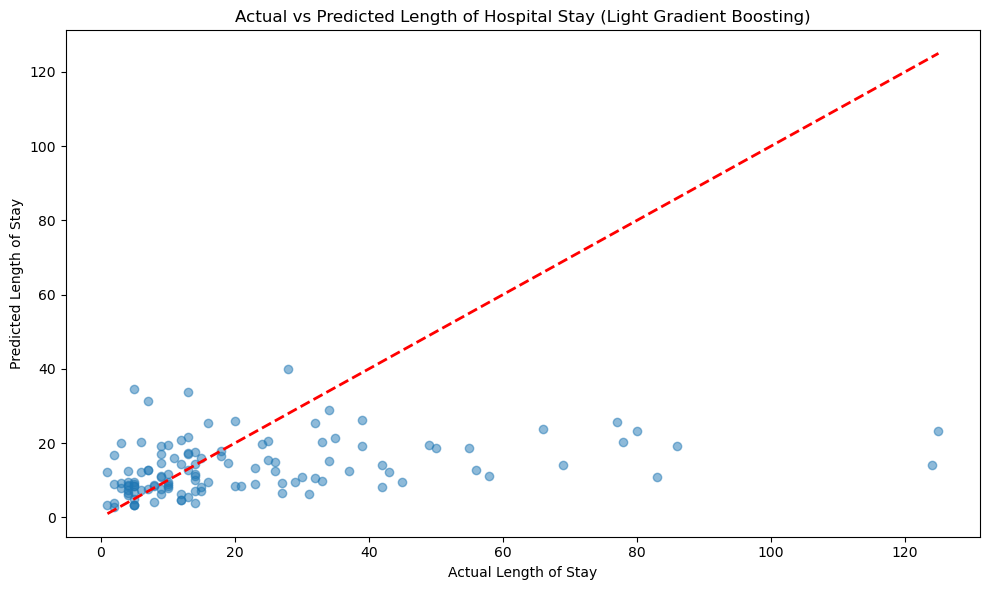

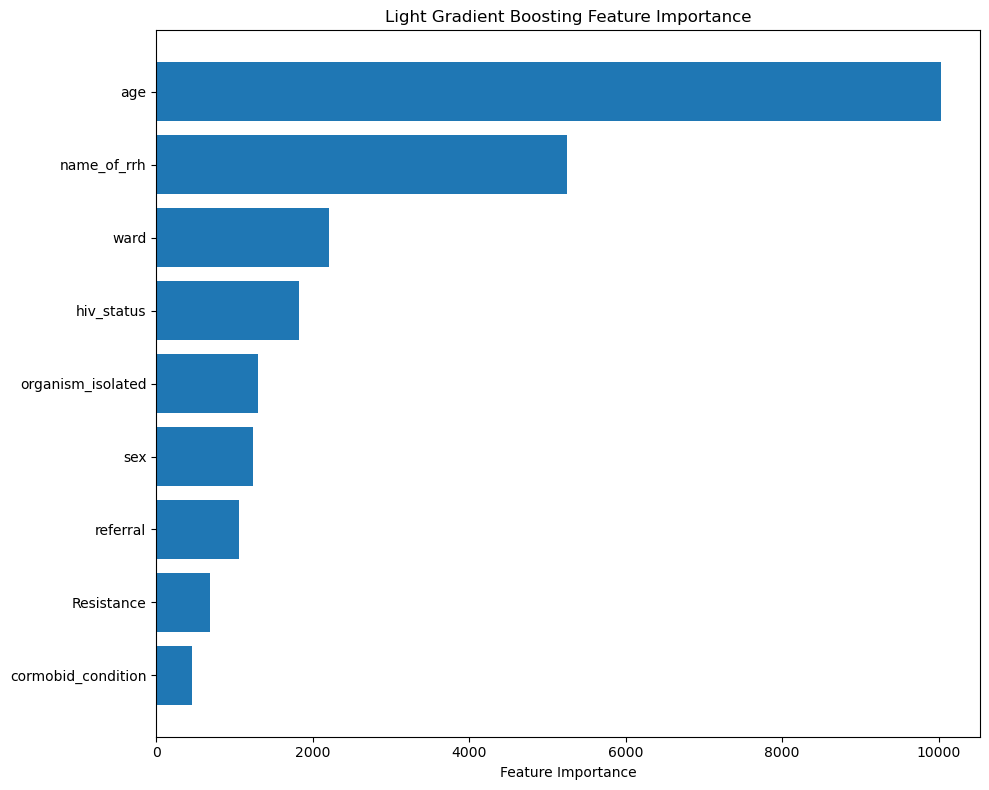

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters for Light Gradient Boosting
params = {
    'objective' : 'regression',
    'random_state': 10,
    'n_estimators': 2000,         # Significantly increased for better fit
    'learning_rate': 0.005,       # Further reduced for more precise corrections
    'max_depth': 4,               # Increased to capture more complex patterns
    'min_child_samples' : 5,
    'num_leaves': 60, 
    'lambda_l2' : 0.012564940721149519,
    'lambda_l1' : 0.0004944664348756718,
    'boosting_type' : 'gbdt',
    'subsample_for_bin'  : 20000               
}

# Initialize and train the Light Gradient Boosting Regressor
lgbm = LGBMRegressor(**params)
lgbm.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = lgbm.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(lgbm, "LGBM_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
          [y_test_original.min(), y_test_original.max()],
          'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Light Gradient Boosting)')
plt.tight_layout()
plt.show()

# Feature importance plot
feature_importance = lgbm.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Light Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow LGBM Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "LGBM_regressor_model")

    # Infer the model signature
    signature = infer_signature(X_train, lgbm.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="LGBM Regressor model",
    )

[LightGBM] [Warning] lambda_l2 is set=0.012564940721149519, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.012564940721149519
[LightGBM] [Warning] lambda_l1 is set=0.0004944664348756718, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004944664348756718


/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'LGBM Regressor model' already exists. Creating a new version of this model...
2025/03/04 12:21:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Mode

🏃 View run stately-foal-427 at: http://127.0.0.1:8080/#/experiments/822887533196691341/runs/711ae874082d4931b5855dda8cad9730
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/822887533196691341


Created version '18' of model 'LGBM Regressor model'.


In [ ]:
import optuna

# Ensure growth is defined
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])  

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define objective function for Optuna
def objective(trial):
    params = {
        'objective': 'regression',
        'boosting_type': 'gbdt',
        'random_state': 10,
        'n_estimators': trial.suggest_int('n_estimators', 1000, 3000, step=500),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.02, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150, step=10),
        'subsample_for_bin': trial.suggest_int('subsample_for_bin', 20000, 50000, step=5000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50, step=5),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    # Train model
    lgbm = LGBMRegressor(**params)
    lgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)])
    
    # Predict and evaluate
    y_pred_log = lgbm.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_original, y_pred)
    return mae  # Minimizing MAE

# Run Optuna optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Get best hyperparameters
best_params = study.best_params 
print("Best hyperparameters:", best_params)

# Train final model with best parameters
lgbm_final = LGBMRegressor(**best_params)
lgbm_final.fit(X_train, y_train)

# Evaluate on test set
y_pred_log = lgbm_final.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log best model with MLflow
with mlflow.start_run():
    mlflow.log_params(best_params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(lgbm_final, "LGBM_regressor_optimized")

# Print final metrics
print(f"Optimized Mean Absolute Error: {mae:.2f}")
print(f"Optimized Root Mean Squared Error: {rmse:.2f}")
print(f"Optimized R-squared Score: {r2:.4f}")

[I 2025-03-04 12:14:19,305] A new study created in memory with name: no-name-b149da80-d7cb-40a0-9c9e-fd3014d6de3b


[LightGBM] [Warning] lambda_l2 is set=0.006499926033757537, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006499926033757537
[LightGBM] [Warning] lambda_l1 is set=0.8477536418545429, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.8477536418545429
[LightGBM] [Warning] lambda_l2 is set=0.006499926033757537, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006499926033757537
[LightGBM] [Warning] lambda_l1 is set=0.8477536418545429, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.8477536418545429
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93
[LightGBM] [Info] Number of data points in the train set: 476, number of used features: 9
[LightGBM] [Warning] lambda_l2 is set=0.006499926033757537, reg_lambda=0.0 will be ignored. Current value: lam

[I 2025-03-04 12:14:22,419] Trial 0 finished with value: 14.077156692591503 and parameters: {'n_estimators': 3000, 'learning_rate': 0.0014778717043910311, 'max_depth': 6, 'num_leaves': 50, 'subsample_for_bin': 30000, 'min_child_samples': 50, 'lambda_l1': 0.8477536418545429, 'lambda_l2': 0.006499926033757537}. Best is trial 0 with value: 14.077156692591503.


[LightGBM] [Warning] lambda_l2 is set=0.006499926033757537, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006499926033757537
[LightGBM] [Warning] lambda_l1 is set=0.8477536418545429, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.8477536418545429
[LightGBM] [Warning] lambda_l2 is set=1.5586117338017833e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5586117338017833e-06
[LightGBM] [Warning] lambda_l1 is set=3.930662176868209e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.930662176868209e-06
[LightGBM] [Warning] lambda_l2 is set=1.5586117338017833e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5586117338017833e-06
[LightGBM] [Warning] lambda_l1 is set=3.930662176868209e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.930662176868209e-06
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And i

[I 2025-03-04 12:14:25,642] Trial 1 finished with value: 14.345730489313814 and parameters: {'n_estimators': 1500, 'learning_rate': 0.0012572994488064923, 'max_depth': 9, 'num_leaves': 50, 'subsample_for_bin': 25000, 'min_child_samples': 20, 'lambda_l1': 3.930662176868209e-06, 'lambda_l2': 1.5586117338017833e-06}. Best is trial 0 with value: 14.077156692591503.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] lambda_l2 is set=0.003902128405280111, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.003902128405280111
[LightGBM] [Warning] lambda_l1 is set=6.363689192560015e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.363689192560015e-08
[LightGBM] [Warning] lambda_l2 is set=0.0054673128773629395, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.005

[I 2025-03-04 12:16:07,067] Trial 49 finished with value: 13.782632962179498 and parameters: {'n_estimators': 2500, 'learning_rate': 0.010938545178892093, 'max_depth': 2, 'num_leaves': 130, 'subsample_for_bin': 50000, 'min_child_samples': 30, 'lambda_l1': 3.6422948738749934e-08, 'lambda_l2': 0.0054673128773629395}. Best is trial 42 with value: 13.635766583899882.


[LightGBM] [Warning] lambda_l2 is set=0.0054673128773629395, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0054673128773629395
[LightGBM] [Warning] lambda_l1 is set=3.6422948738749934e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.6422948738749934e-08
Best hyperparameters: {'n_estimators': 2000, 'learning_rate': 0.011537098443762819, 'max_depth': 2, 'num_leaves': 140, 'subsample_for_bin': 50000, 'min_child_samples': 25, 'lambda_l1': 4.11520216543664e-08, 'lambda_l2': 0.0521652919021581}
[LightGBM] [Warning] lambda_l2 is set=0.0521652919021581, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0521652919021581
[LightGBM] [Warning] lambda_l1 is set=4.11520216543664e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.11520216543664e-08
[LightGBM] [Warning] lambda_l2 is set=0.0521652919021581, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0521652919021581
[LightGBM] [Warning] lambda_l1 is set=4.11520216543664e-08, reg_alpha=0.0 

2025/03/04 12:16:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run stylish-penguin-494 at: http://127.0.0.1:8080/#/experiments/822887533196691341/runs/fe96208bdb734146be211136613009d4
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/822887533196691341
Optimized Mean Absolute Error: 13.64
Optimized Root Mean Squared Error: 23.22
Optimized R-squared Score: 0.0231


# Extreme gradient boost

/home/kyomukama/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:16:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "copy_X", "fit_intercept", "max_dept", "max_iter", "positive" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] lambda_l2 is set=0.012564940721149519, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.012564940721149519
[LightGBM] [Warning] lambda_l1 is set=0.0004944664348756718, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004944664348756718


/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run delightful-sheep-311 at: http://127.0.0.1:8080/#/experiments/822887533196691341/runs/ee3537a5dd5040f5b094426006c755c9
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/822887533196691341
Mean Absolute Error: 14.24
Root Mean Squared Error: 23.81
R-squared Score: -0.0274


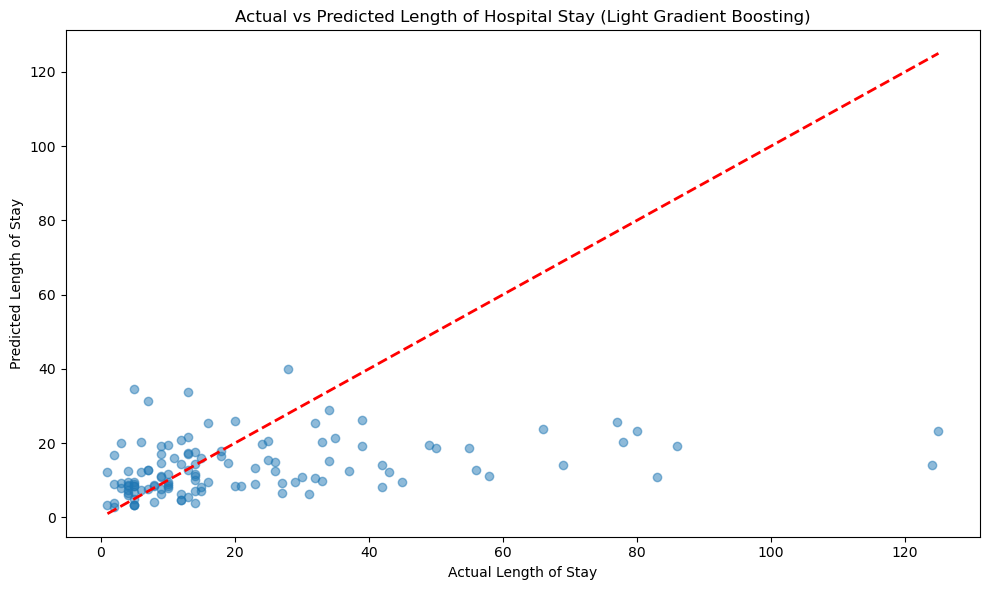

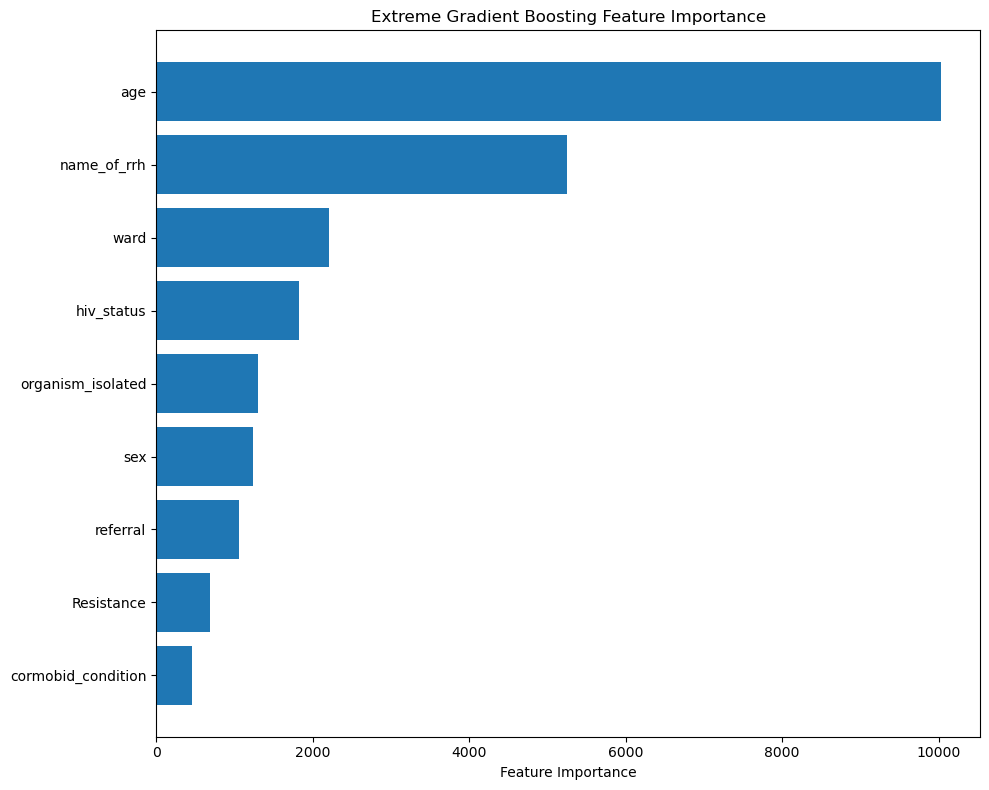

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters for Light Gradient Boosting
params = {
    'positive' : True,
    'random_state': 10,
    'max_iter': 2000,        
    'alpha': 0.005,   
    'fit_intercept': True,               
    'copy_X': True,
    'max_dept': 4,
    'subsample': 1,
    'n_estimators': 1000           
}

# Initialize and train the Light Gradient Boosting Regressor
xgb = XGBRegressor(**params)
xgb.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = lgbm.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(xgb, "LGBM_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
          [y_test_original.min(), y_test_original.max()],
          'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Light Gradient Boosting)')
plt.tight_layout()
plt.show()

# Feature importance plot
feature_importance = lgbm.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Extreme Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow XGB Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "XGB_regressor_model")

    # Infer the model signature
    signature = infer_signature(X_train, lgbm.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="XGB Regressor model",
    )

[LightGBM] [Warning] lambda_l2 is set=0.012564940721149519, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.012564940721149519
[LightGBM] [Warning] lambda_l1 is set=0.0004944664348756718, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004944664348756718


/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'XGB Regressor model' already exists. Creating a new version of this model...
2025/03/04 12:16:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model

🏃 View run sedate-foal-754 at: http://127.0.0.1:8080/#/experiments/317490332836945887/runs/d6582d77608745e291b18e2b66ea91da
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/317490332836945887


Created version '17' of model 'XGB Regressor model'.


# Lass regressor

/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run placid-newt-355 at: http://127.0.0.1:8080/#/experiments/317490332836945887/runs/a5ff4e20720a4fd0881aa314855420f2
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/317490332836945887
Mean Absolute Error: 14.58
Root Mean Squared Error: 24.25
R-squared Score: -0.0655


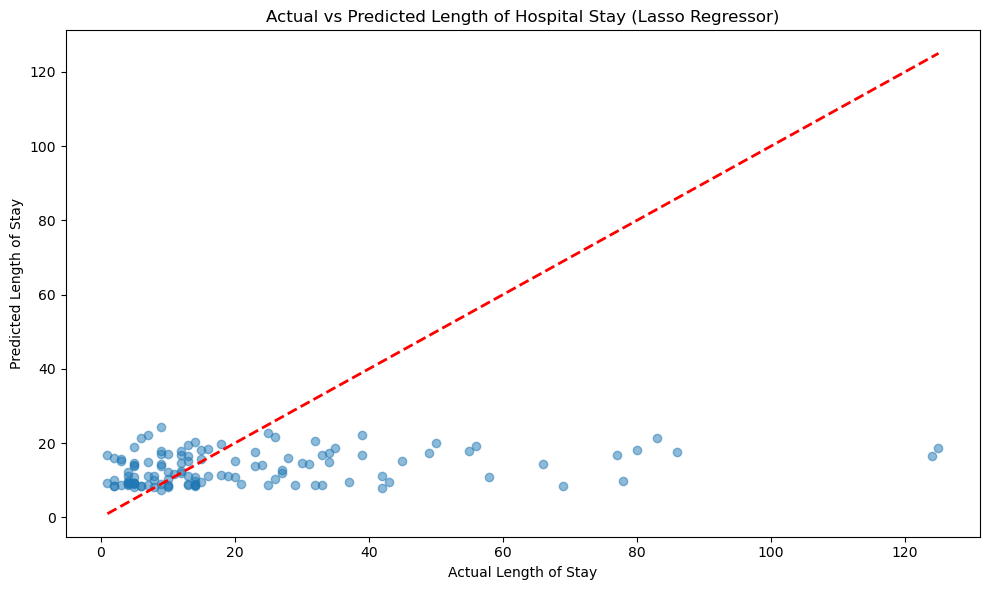

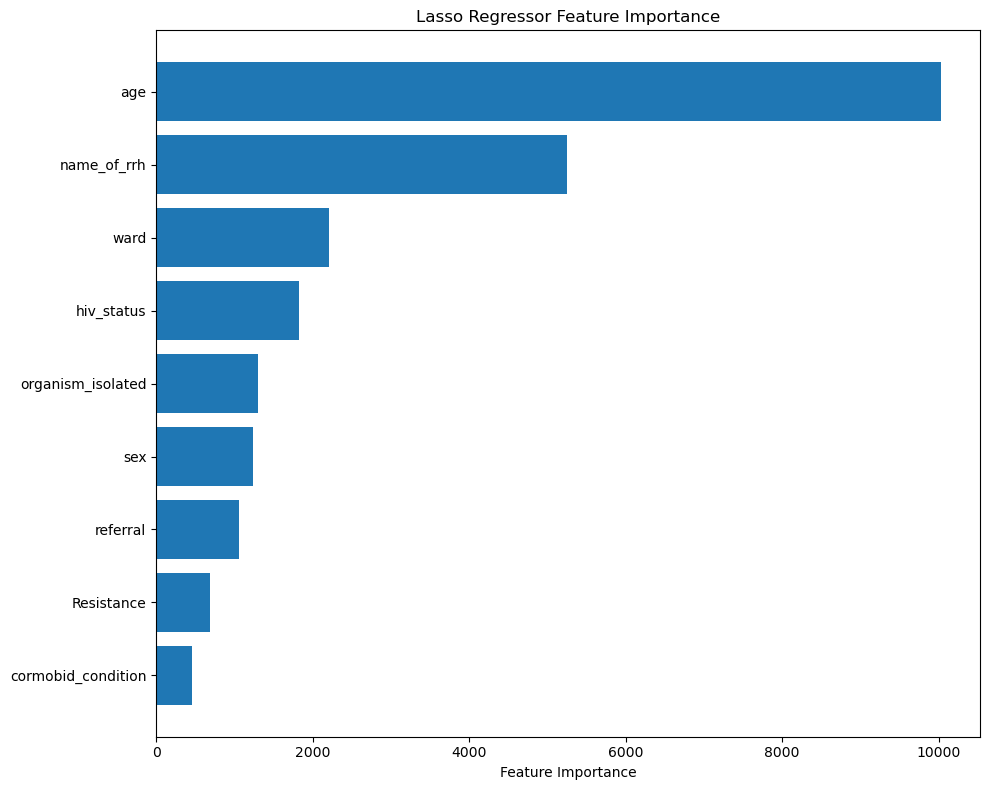

In [ ]:
from sklearn.linear_model import Lasso

# Apply log transformation to the target variable
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters for Light Gradient Boosting
params = {
    'random_state':10,
    'alpha' : 00.006551,
    'fit_intercept' : True,
    'copy_X' : True,
    'max_iter' : 1500,
    'positive' : True
}


# Initialize and train the Light Gradient Boosting Regressor
lasso = Lasso(**params)
lasso.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = lasso.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(lasso, "Lasso_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
          [y_test_original.min(), y_test_original.max()],
          'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Lasso Regressor)')
plt.tight_layout()
plt.show()

# Feature importance plot
feature_importance = lgbm.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Lasso Regressor Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow Lasso Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Lasso_regressor_model")

    # Infer the model signature
    signature = infer_signature(X_train, lgbm.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="Lasso Regressor model",
    )

[LightGBM] [Warning] lambda_l2 is set=0.012564940721149519, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.012564940721149519
[LightGBM] [Warning] lambda_l1 is set=0.0004944664348756718, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004944664348756718


/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'Lasso Regressor model' already exists. Creating a new version of this model...
2025/03/04 12:16:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Mod

🏃 View run rambunctious-pug-305 at: http://127.0.0.1:8080/#/experiments/630657385198661799/runs/43b767c290fc4cb58e0955fab6d84168
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/630657385198661799


Created version '14' of model 'Lasso Regressor model'.


Best alpha from cross-validation: 0.005429
CV Mean Absolute Error: 0.7383 ± 0.0928
CV Root Mean Squared Error: 0.9324 ± 0.0879
CV R-squared Score: 0.0540 ± 0.1112


/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run valuable-kit-951 at: http://127.0.0.1:8080/#/experiments/630657385198661799/runs/e2a7f9c59baa4234859a48fc3529b017
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/630657385198661799
Test Mean Absolute Error: 14.58
Test Root Mean Squared Error: 24.24
Test R-squared Score: -0.0647


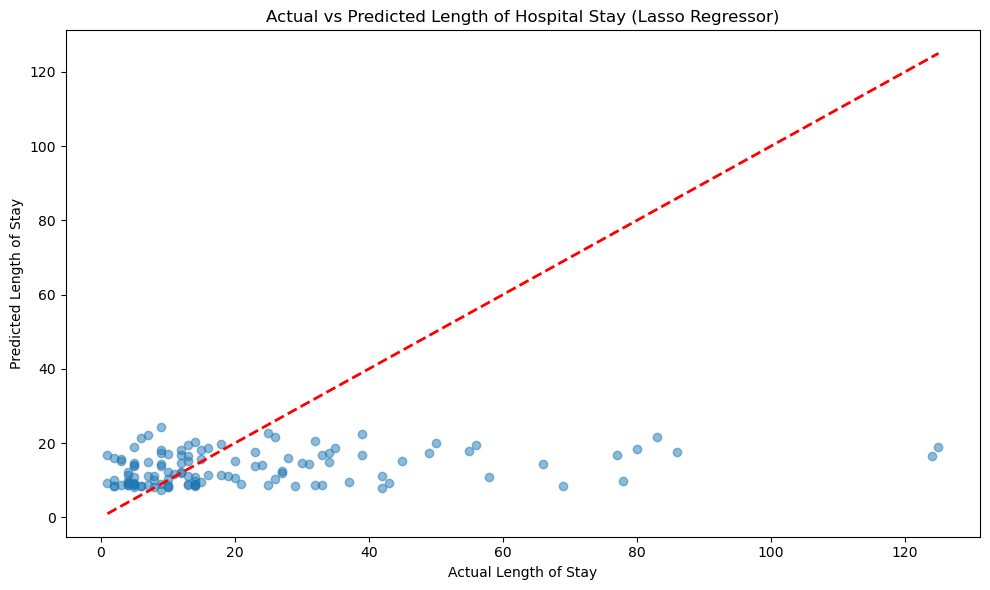

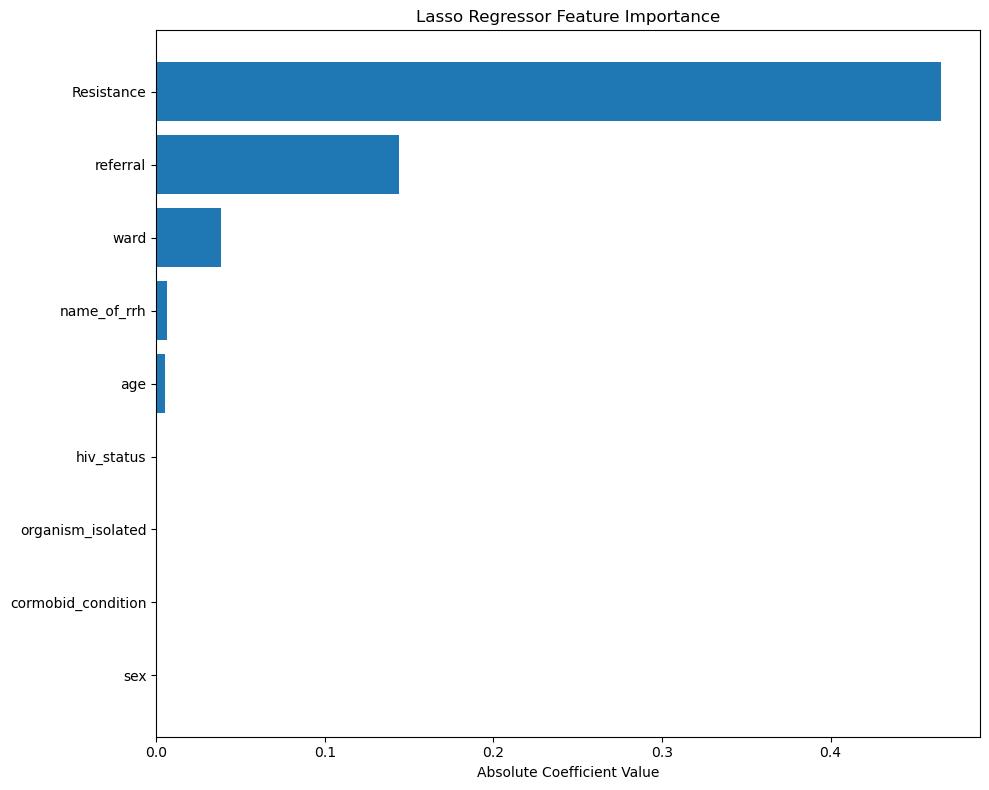

In [ ]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Apply log transformation to the target variable
X = growth1.drop(columns='length_hosp_stay')
y = np.log1p(growth1['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. First approach: Cross-validation to find optimal alpha
alphas = np.logspace(-3, 1, 50)  # Range of alphas to test
lasso_cv = LassoCV(
    alphas=alphas,
    cv=25,
    random_state=10,
    max_iter=1500,
    positive=True,
    fit_intercept=True
)

# Fit the model
lasso_cv.fit(X_train, y_train)

# Get the best alpha
best_alpha = lasso_cv.alpha_
print(f"Best alpha from cross-validation: {best_alpha:.6f}")

# 2. Second approach: Cross-validation for model evaluation
params = {
    'random_state': 10,
    'alpha': best_alpha,  # Use the best alpha found
    'fit_intercept': True,
    'copy_X': True,
    'max_iter': 1500,
    'positive': True
}

# Initialize the model with the best parameters
lasso = Lasso(**params)

# Setup cross-validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validate and evaluate
cv_mae = -cross_val_score(lasso, X_train, y_train, cv=cv, 
                         scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(lasso, X_train, y_train, cv=cv, 
                                 scoring='neg_mean_squared_error', n_jobs=-1))
cv_r2 = cross_val_score(lasso, X_train, y_train, cv=cv, 
                       scoring='r2', n_jobs=-1)

# Print cross-validation results
print(f"CV Mean Absolute Error: {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"CV Root Mean Squared Error: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"CV R-squared Score: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# Train the final model with the best parameters on the full training set
final_lasso = Lasso(**params)
final_lasso.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = final_lasso.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("best_alpha", best_alpha)
    mlflow.log_metric("cv_mae_mean", cv_mae.mean())
    mlflow.log_metric("cv_rmse_mean", cv_rmse.mean())
    mlflow.log_metric("cv_r2_mean", cv_r2.mean())
    mlflow.log_metric("test_mae", mae)
    mlflow.log_metric("test_mse", mse)
    mlflow.log_metric("test_rmse", rmse)
    mlflow.log_metric("test_r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred_log)
    mlflow.sklearn.log_model(final_lasso, "Lasso_regressor_model", signature=signature)

# Print the test metrics
print(f"Test Mean Absolute Error: {mae:.2f}")
print(f"Test Root Mean Squared Error: {rmse:.2f}")
print(f"Test R-squared Score: {r2:.4f}")

# Scatter plot for predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Lasso Regressor)')
plt.tight_layout()
plt.show()

# Feature importance plot for Lasso using absolute coefficient values
feature_importance = np.abs(final_lasso.coef_)
feature_names = X.columns
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel('Absolute Coefficient Value')
plt.title('Lasso Regressor Feature Importance')
plt.tight_layout()
plt.show()